# iFood Customer Segmentation Analysis

본 노트북은 iFood 고객 데이터를 기반으로  
연령별 구매 채널 선호, 할인 민감도, 캠페인 응답 여부에 따른 고객 특성 차이를 분석한다.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

BASE_DIR = Path("..") if (Path("..") / "data").exists() else Path(".")
DATA_PATH = BASE_DIR / "data" / "marketing_campaign.csv"
FIG_DIR = BASE_DIR / "reports" / "figures"
TABLE_DIR = BASE_DIR / "reports" / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH, sep = '\t')

# Feature engineering
df["Age"] = 2014 - df["Year_Birth"]
df["Children_Count"] = df["Kidhome"] + df["Teenhome"]

spend_cols = [
    "MntWines", "MntFruits", "MntMeatProducts",
    "MntFishProducts", "MntSweetProducts", "MntGoldProds"
]
df["Total_Spent"] = df[spend_cols].sum(axis=1)

purchase_cols = [
    "NumWebPurchases", "NumCatalogPurchases",
    "NumStorePurchases", "NumDealsPurchases"
]
df["Total_Purchase_Count"] = df[purchase_cols].sum(axis=1)

df["Discount_Purchase_Ratio"] = np.where(
    df["Total_Purchase_Count"] > 0,
    df["NumDealsPurchases"] / df["Total_Purchase_Count"],
    np.nan
)

# Response column
if "Response" in df.columns:
    df["Responded_Label"] = df["Response"].map({1: "Responded", 0: "Non-responded"})
else:
    raise ValueError("Response column not found.")

# Age group
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0, 29, 39, 49, 59, 200],
    labels=["20s", "30s", "40s", "50s", "60+"]
)

# Income group (quartiles)
df_income = df.dropna(subset=["Income"]).copy()
df_income["Income_Group"] = pd.qcut(
    df_income["Income"],
    q=4,
    labels=["low", "low_middle", "middle_high", "high"]
)

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Z_CostContact,Z_Revenue,Response,Age,Children_Count,Total_Spent,Total_Purchase_Count,Discount_Purchase_Ratio,Responded_Label,Age_Group
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,3,11,1,57,0,1617,25,0.120000,Responded,50s
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,3,11,0,60,2,27,6,0.333333,Non-responded,60+
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,3,11,0,49,0,776,21,0.047619,Non-responded,40s
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,11,0,30,1,53,8,0.250000,Non-responded,30s
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,3,11,0,33,1,422,19,0.263158,Non-responded,30s


## Age × Channel Preference

연령대별로 Web / Store / Catalog 구매 비중을 비교한다.
Deals(할인 구매)는 채널이 아니라 프로모션 활용이므로 여기서는 제외한다.

C:\Users\poulj\AppData\Local\Temp\ipykernel_14920\4290711108.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_channel = df.groupby("Age_Group")[["NumWebPurchases", "NumStorePurchases", "NumCatalogPurchases"]].mean()


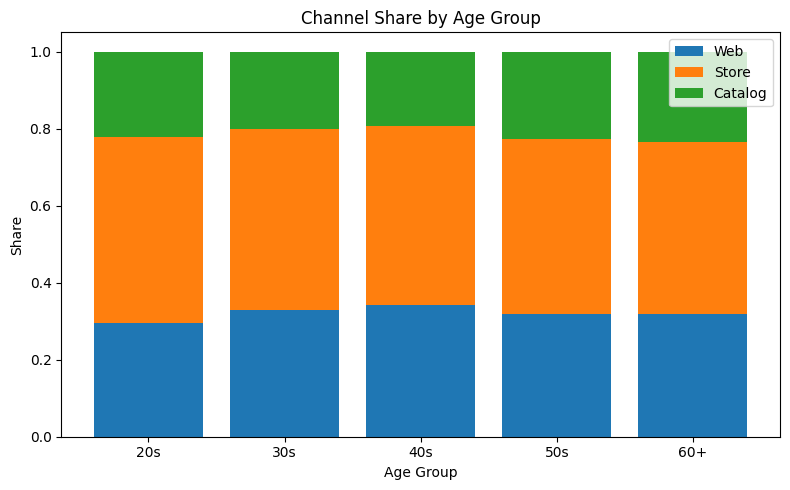

In [2]:
age_channel = df.groupby("Age_Group")[["NumWebPurchases", "NumStorePurchases", "NumCatalogPurchases"]].mean()
age_channel_share = age_channel.div(age_channel.sum(axis=1), axis=0)

age_channel_share.to_csv(TABLE_DIR / "age_channel_share.csv")

plt.figure(figsize=(8, 5))
bottom = np.zeros(len(age_channel_share))
for col, label in zip(
    ["NumWebPurchases", "NumStorePurchases", "NumCatalogPurchases"],
    ["Web", "Store", "Catalog"]
):
    plt.bar(age_channel_share.index.astype(str), age_channel_share[col], bottom=bottom, label=label)
    bottom += age_channel_share[col].values

plt.title("Channel Share by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Share")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "01_age_channel_share.png", dpi=150)
plt.show()

## Discount Sensitivity

자녀 수와 소득 수준에 따라 할인 구매 비중이 어떻게 달라지는지 확인한다.

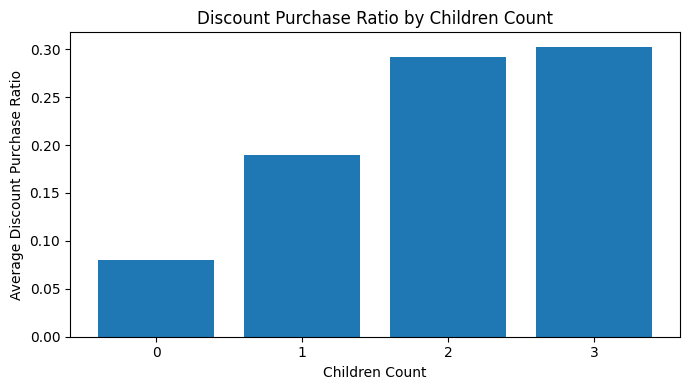

In [3]:
# Children Count × Discount Ratio

children_discount = df.groupby("Children_Count")["Discount_Purchase_Ratio"].mean().reset_index()
children_discount.to_csv(TABLE_DIR / "children_discount_ratio.csv", index=False)

plt.figure(figsize=(7, 4))
plt.bar(children_discount["Children_Count"].astype(str), children_discount["Discount_Purchase_Ratio"])
plt.title("Discount Purchase Ratio by Children Count")
plt.xlabel("Children Count")
plt.ylabel("Average Discount Purchase Ratio")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_children_discount_ratio.png", dpi=150)
plt.show()

C:\Users\poulj\AppData\Local\Temp\ipykernel_14920\3796042726.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_discount = df_income.groupby("Income_Group")["Discount_Purchase_Ratio"].mean().reset_index()


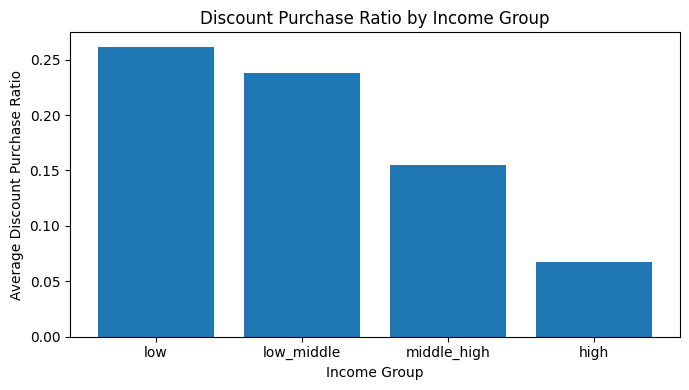

In [4]:
# Income Group × Discount Ratio

income_discount = df_income.groupby("Income_Group")["Discount_Purchase_Ratio"].mean().reset_index()
income_discount.to_csv(TABLE_DIR / "income_discount_ratio.csv", index=False)

plt.figure(figsize=(7, 4))
plt.bar(income_discount["Income_Group"].astype(str), income_discount["Discount_Purchase_Ratio"])
plt.title("Discount Purchase Ratio by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Average Discount Purchase Ratio")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_income_discount_ratio.png", dpi=150)
plt.show()

## Responders vs Non-responders

캠페인 응답 고객과 비응답 고객의  
총 구매금액, 웹사이트 방문 수, 할인 구매 비중을 비교한다.

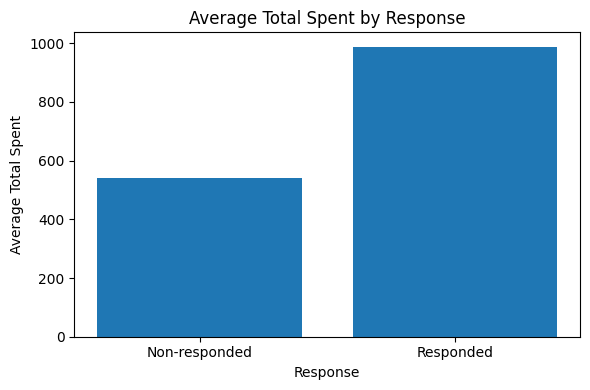

In [5]:
# Total Spent

resp_summary = df.groupby("Responded_Label").agg(
    Total_Spent_Mean=("Total_Spent", "mean"),
    NumWebVisitsMonth_Mean=("NumWebVisitsMonth", "mean"),
    Discount_Purchase_Ratio_Mean=("Discount_Purchase_Ratio", "mean")
).reset_index()

resp_summary.to_csv(TABLE_DIR / "response_summary.csv", index=False)

plt.figure(figsize=(6, 4))
plt.bar(resp_summary["Responded_Label"], resp_summary["Total_Spent_Mean"])
plt.title("Average Total Spent by Response")
plt.xlabel("Response")
plt.ylabel("Average Total Spent")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_response_total_spent.png", dpi=150)
plt.show()

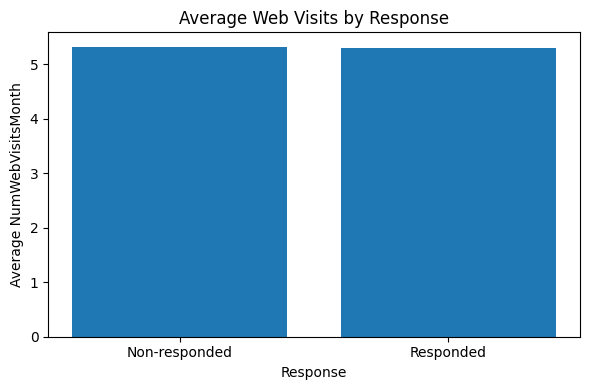

In [6]:
# Web Visists

plt.figure(figsize=(6, 4))
plt.bar(resp_summary["Responded_Label"], resp_summary["NumWebVisitsMonth_Mean"])
plt.title("Average Web Visits by Response")
plt.xlabel("Response")
plt.ylabel("Average NumWebVisitsMonth")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_response_web_visits.png", dpi=150)
plt.show()

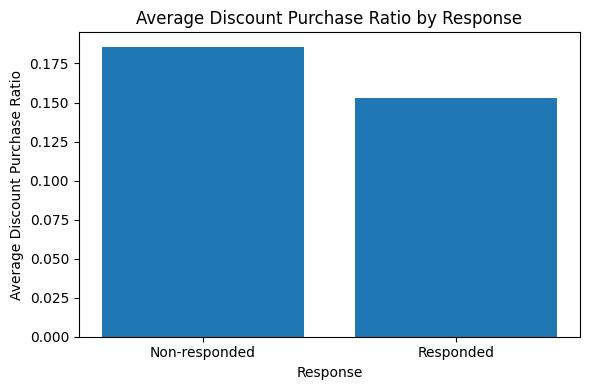

In [7]:
# Discount Ratio

plt.figure(figsize=(6, 4))
plt.bar(resp_summary["Responded_Label"], resp_summary["Discount_Purchase_Ratio_Mean"])
plt.title("Average Discount Purchase Ratio by Response")
plt.xlabel("Response")
plt.ylabel("Average Discount Purchase Ratio")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_response_discount_ratio.png", dpi=150)
plt.show()

## Final Insights

### 일일 지표 흐름
(이 iFood 프로젝트에서는 daily trend보다 세그먼트 분석이 중심이므로 생략 가능)

### 카테고리/세그먼트 인사이트
- 30~40대는 Web 구매 비중이 상대적으로 높게 나타났다.
- 20대는 Store 구매 비중이 상대적으로 높게 나타났다.
- 50대 이상에서는 Catalog 구매 비중이 상대적으로 높게 나타났다.
- 자녀 수가 많을수록 할인 프로모션 활용 비중이 증가하는 경향이 나타났다.
- 소득 수준이 낮을수록 할인 프로모션 활용 비중이 높게 나타났다.
- 캠페인 응답 고객은 비응답 고객보다 총 구매금액이 높게 나타났다.
- 웹사이트 방문 수는 응답 고객과 비응답 고객 간 뚜렷한 차이가 확인되지 않았다.
- 비응답 고객은 응답 고객보다 할인 구매 비중이 더 높게 나타났다.